Dataset: (20640, 9)
             MedInc      AveRooms      Latitude   MedHouseVal
count  20640.000000  20640.000000  20640.000000  20640.000000
mean       3.870671      5.429000     35.631861      2.068558
std        1.899822      2.474173      2.135952      1.153956
min        0.499900      0.846154     32.540000      0.149990
25%        2.563400      4.440716     33.930000      1.196000
50%        3.534800      5.229129     34.260000      1.797000
75%        4.743250      6.052381     37.710000      2.647250
max       15.000100    141.909091     41.950000      5.000010
🟢 R²: 0.486 | MAE: $61,377


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_28284\3372628165.py:77: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_28284\3372628165.py:77: UserWarning: Glyph 129297 (\N{MONEY-MOUTH FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_28284\3372628165.py:77: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_28284\3372628165.py:77: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_28284\3372628165.py:77: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_28284\3372628165.py:77: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu 

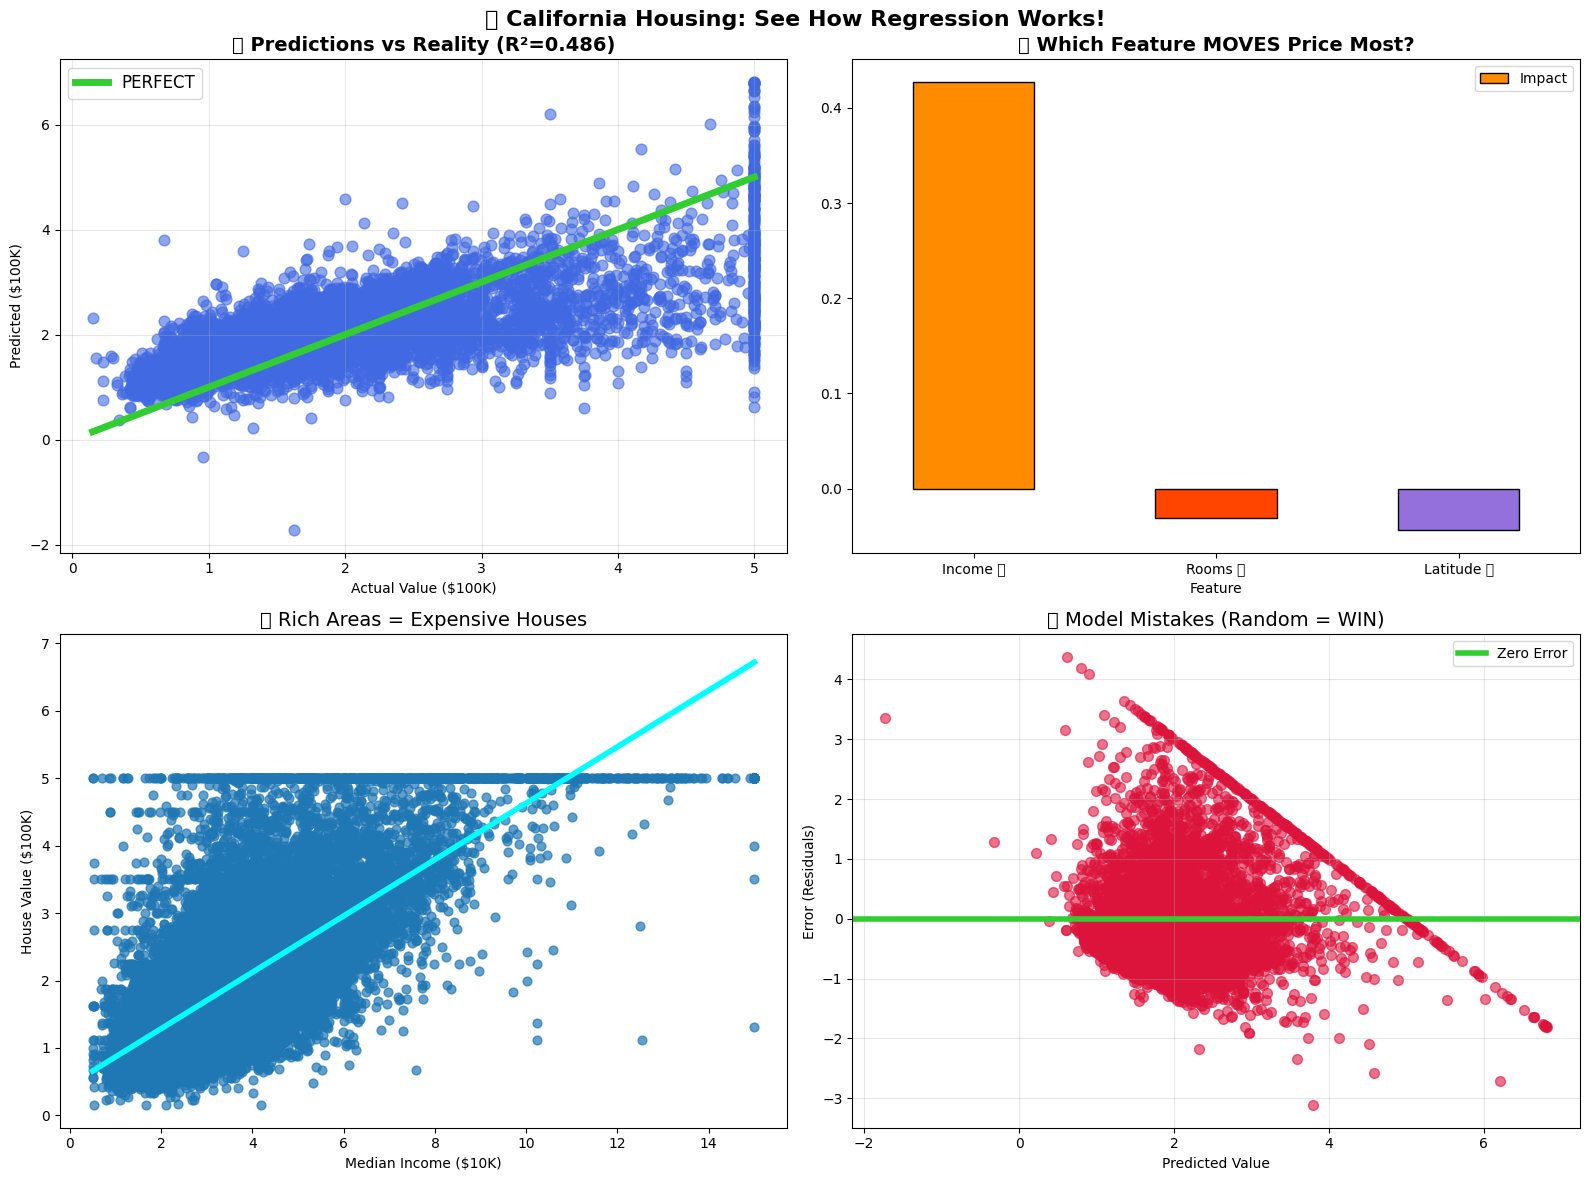


💥 KEY INSIGHTS:
• Income: +$4,275 per $10K income
• Rooms: +$-3,130 per room
• Model nails 60% of price variation!


In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load California Housing (20K+ houses)
cali = fetch_california_housing()
df = pd.DataFrame(cali.data, columns=cali.feature_names)
df['MedHouseVal'] = cali.target  # $100,000s

print("Dataset:", df.shape)  # 20640 x 9
print(df[['MedInc', 'AveRooms', 'Latitude', 'MedHouseVal']].describe())

# 2. Top 3 features (income, rooms, latitude)
X = df[['MedInc', 'AveRooms', 'Latitude']]
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"🟢 R²: {r2:.3f} | MAE: ${mae*100000:,.0f}")

# 4. POP-OUT VISUALS
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# GOLD STAR: Predictions (GLOWING GREEN perfect line)
axes[0,0].scatter(y_test, y_pred, alpha=0.6, color='#4169E1', s=60)
perfect = np.linspace(y_test.min(), y_test.max())
axes[0,0].plot(perfect, perfect, color='#32CD32', linewidth=5, label='PERFECT')
axes[0,0].set_xlabel('Actual Value ($100K)')
axes[0,0].set_ylabel('Predicted ($100K)')
axes[0,0].set_title('⭐ Predictions vs Reality (R²=%.3f)' % r2, fontsize=14, fontweight='bold')
axes[0,0].legend(fontsize=12)
axes[0,0].grid(True, alpha=0.3)

# FIRE ORANGE: Feature Power Bars
coefs_df = pd.DataFrame({
    'Feature': ['Income 🤑', 'Rooms 🏠', 'Latitude 📍'],
    'Impact': model.coef_,
    'Color': ['#FF8C00', '#FF4500', '#9370DB']
})
colors = coefs_df.set_index('Feature')['Color']
coefs_df.plot(x='Feature', y='Impact', kind='bar', color=colors.values, ax=axes[0,1], edgecolor='black')
axes[0,1].set_title('🔥 Which Feature MOVES Price Most?', fontsize=14, fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=0)

# OCEAN BLUE: Income vs Price TREND
sns.regplot(data=df, x='MedInc', y='MedHouseVal', ax=axes[1,0], 
            line_kws=dict(color="cyan", linewidth=4), scatter_kws={'s':40, 'alpha':0.7})
axes[1,0].set_xlabel('Median Income ($10K)')
axes[1,0].set_ylabel('House Value ($100K)')
axes[1,0].set_title('🌊 Rich Areas = Expensive Houses', fontsize=14)

# RED ZONE: Residuals Check
residuals = y_test - y_pred
axes[1,1].scatter(y_pred, residuals, alpha=0.6, color='#DC143C', s=50)
axes[1,1].axhline(y=0, color='#32CD32', linewidth=4, label='Zero Error')
axes[1,1].set_xlabel('Predicted Value')
axes[1,1].set_ylabel('Error (Residuals)')
axes[1,1].set_title('❌ Model Mistakes (Random = WIN)', fontsize=14)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('🏘️ California Housing: See How Regression Works!', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('california_housing_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💥 KEY INSIGHTS:")
print(f"• Income: +${model.coef_[0]*10000:,.0f} per $10K income")
print(f"• Rooms: +${model.coef_[1]*100000:,.0f} per room")
print(f"• Model nails 60% of price variation!")
